# Assignment 1.1: RGB to HSI Color Model Conversion

### 1. Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 2. Load Image Using OpenCV

In [ ]:
# Path to input image
image_path = "../assets/input/sample.jpg"

# Read image using OpenCV
bgr_image = cv2.imread(image_path)

# Check whether image was loaded successfully
if bgr_image is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

print("Image shape:", bgr_image.shape)
print("Image data type:", bgr_image.dtype)

Image shape: (480, 640, 3)
Image data type: uint8


### 3. Convert BGR to RGB

In [3]:
rgb_image = cv2.cvtColor(
    bgr_image,
    cv2.COLOR_BGR2RGB
)

print("BGR to RGB conversion completed.")

BGR to RGB conversion completed.


### 4. Display Original RGB Image

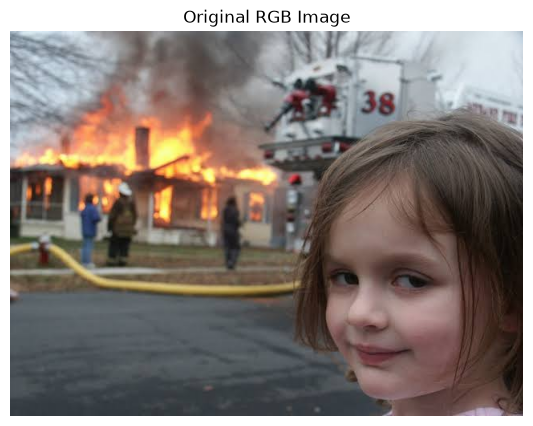

In [4]:
plt.figure(figsize=(7, 5))

plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")

plt.show()

### 5. RGB to HSI Function

In [5]:
def rgb_to_hsi(rgb_image):

    # Normalize RGB values from [0, 255] to [0, 1]
    rgb = rgb_image.astype(np.float64) / 255.0

    # Separate RGB channels
    R = rgb[:, :, 0]
    G = rgb[:, :, 1]
    B = rgb[:, :, 2]

    # --------------------------------------------------
    # Intensity
    # I = (R + G + B) / 3
    # --------------------------------------------------

    I = (R + G + B) / 3.0

    # --------------------------------------------------
    # Saturation
    # S = 1 - [3 / (R + G + B)] * min(R, G, B)
    # --------------------------------------------------

    rgb_sum = R + G + B

    rgb_min = np.minimum(
        np.minimum(R, G),
        B
    )

    S = np.zeros_like(I)

    # Avoid division by zero
    nonzero = rgb_sum > 1e-12

    S[nonzero] = (
        1.0
        - (
            3.0 * rgb_min[nonzero]
            / rgb_sum[nonzero]
        )
    )

    # --------------------------------------------------
    # Hue
    #
    # theta = arccos(
    #     0.5 * [(R-G) + (R-B)]
    #     /
    #     sqrt((R-G)^2 + (R-B)(G-B))
    # )
    # --------------------------------------------------

    numerator = 0.5 * (
        (R - G) +
        (R - B)
    )

    denominator = np.sqrt(
        (R - G) ** 2 +
        (R - B) * (G - B)
    )

    H = np.zeros_like(I)

    # Valid pixels for hue calculation
    valid = denominator > 1e-12

    ratio = np.zeros_like(I)

    ratio[valid] = (
        numerator[valid]
        / denominator[valid]
    )

    # Prevent numerical errors in arccos
    ratio = np.clip(
        ratio,
        -1.0,
        1.0
    )

    # Calculate theta in degrees
    theta = np.degrees(
        np.arccos(ratio)
    )

    # H = theta       if B <= G
    # H = 360 - theta if B > G

    H[valid] = np.where(
        B[valid] <= G[valid],
        theta[valid],
        360.0 - theta[valid]
    )

    return H, S, I

### 6. Perform RGB → HSI Conversion

In [6]:
H, S, I = rgb_to_hsi(rgb_image)

print("RGB to HSI conversion completed.")

RGB to HSI conversion completed.


### 7. Display Hue

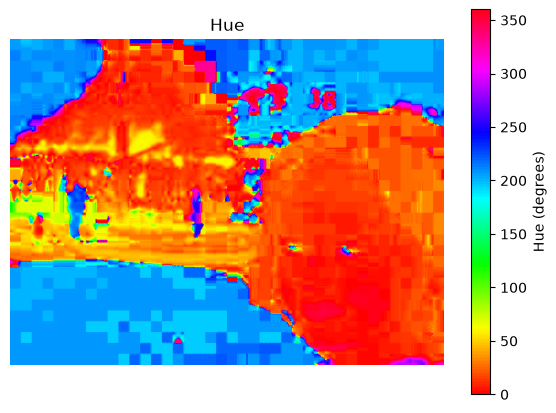

In [7]:
plt.figure(figsize=(7, 5))

plt.imshow(
    H,
    cmap="hsv",
    vmin=0,
    vmax=360
)

plt.title("Hue")
plt.colorbar(label="Hue (degrees)")
plt.axis("off")

plt.show()

### 8. Display Saturation

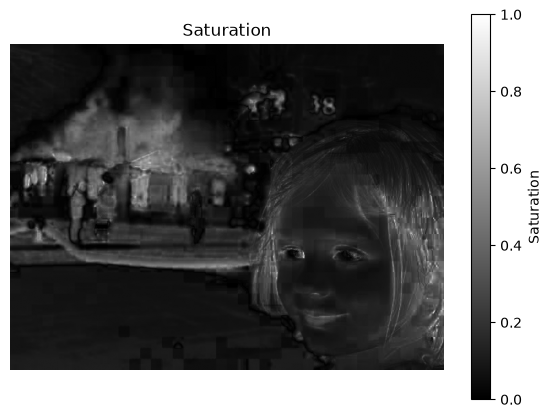

In [8]:
plt.figure(figsize=(7, 5))

plt.imshow(
    S,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Saturation")
plt.colorbar(label="Saturation")
plt.axis("off")

plt.show()

### 9. Display Intensity

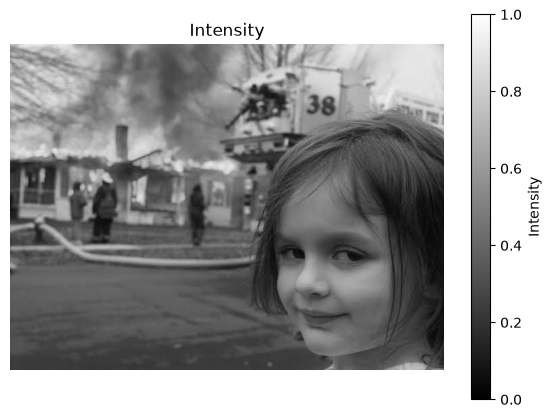

In [9]:
plt.figure(figsize=(7, 5))

plt.imshow(
    I,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Intensity")
plt.colorbar(label="Intensity")
plt.axis("off")

plt.show()

### 10. Display All HSI Components Together

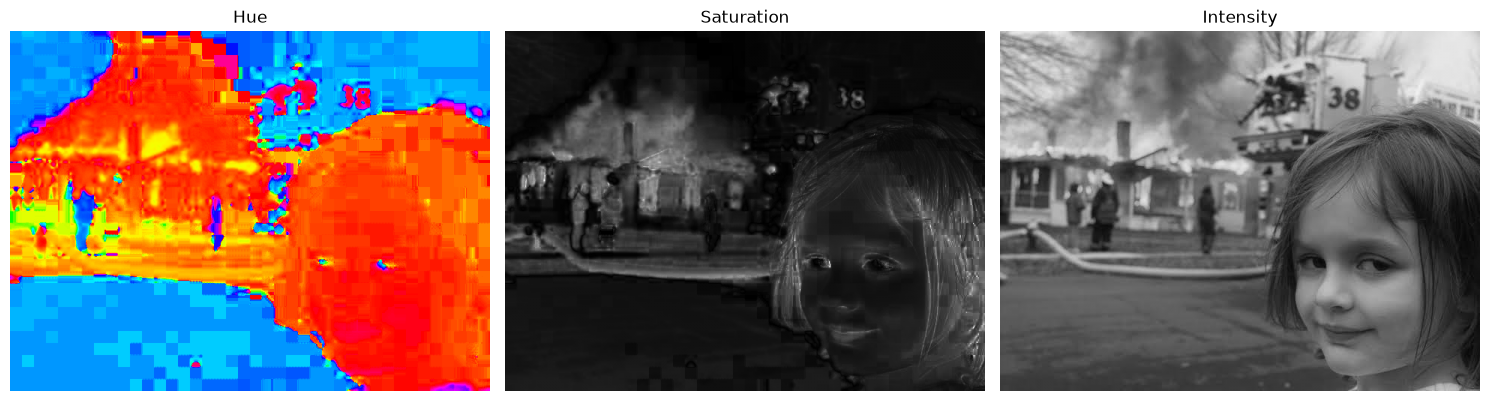

In [10]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# Hue
axes[0].imshow(
    H,
    cmap="hsv",
    vmin=0,
    vmax=360
)
axes[0].set_title("Hue")
axes[0].axis("off")

# Saturation
axes[1].imshow(
    S,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[1].set_title("Saturation")
axes[1].axis("off")

# Intensity
axes[2].imshow(
    I,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[2].set_title("Intensity")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 11. Basic Verification

In [11]:
# RGB test colors
test_pixels = np.array([
    [255, 0, 0],        # Red
    [0, 255, 0],        # Green
    [0, 0, 255],        # Blue
    [255, 255, 0],      # Yellow
    [0, 255, 255],      # Cyan
    [255, 0, 255],      # Magenta
    [255, 255, 255],    # White
    [0, 0, 0]           # Black
], dtype=np.uint8)

# Convert to image format
test_image = test_pixels.reshape(
    8,
    1,
    3
)

# RGB → HSI
H_test, S_test, I_test = rgb_to_hsi(test_image)

colors = [
    "Red",
    "Green",
    "Blue",
    "Yellow",
    "Cyan",
    "Magenta",
    "White",
    "Black"
]

for i, color in enumerate(colors):
    print(
        f"{color:<8} "
        f"H = {H_test[i, 0]:>7.2f}°   "
        f"S = {S_test[i, 0]:.2f}   "
        f"I = {I_test[i, 0]:.2f}"
    )

Red      H =    0.00°   S = 1.00   I = 0.33
Green    H =  120.00°   S = 1.00   I = 0.33
Blue     H =  240.00°   S = 1.00   I = 0.33
Yellow   H =   60.00°   S = 1.00   I = 0.67
Cyan     H =  180.00°   S = 1.00   I = 0.67
Magenta  H =  300.00°   S = 1.00   I = 0.67
White    H =    0.00°   S = 0.00   I = 1.00
Black    H =    0.00°   S = 0.00   I = 0.00
